In [3]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt


## Cbhim Analysis

In [4]:
# load datasets

# load 1D 
with h5py.File(
    'datasets/new_Input_bbyy_SMEFT_cbhim_23rdJanuary_2026.h5',
    'r'
) as f:
    cbhim_1D_df = pd.DataFrame.from_records(f['ForAnalysis/1d'][:])
    
# load 2D
with h5py.File(
    'datasets/new_Input_bbyy_SMEFT_cbhim_23rdJanuary_2026.h5',
    'r'
) as f:
    objects = f['ForAnalysis/2d'][:] 

weights = cbhim_1D_df['Lumi_weight']
label   = cbhim_1D_df['is_HiggsEvent']   # True = signal

In [5]:
cbhim_1D_df.head()

,DPhi_bb,Eta_jj,EventNumber,Higgs_Eta,Higgs_Mass,Higgs_Phi,Higgs_pT,LeadJet_Eta,LeadJet_M,LeadJet_Phi,...,SubLeadPhoton_Phi,SubLeadPhoton_pT,cosThetaStar,costheta1,costheta2,is_HiggsEvent,m_bbyy,nBTaggedJets,pT_jj,signed_DeltaPhi_jj
0,2.563771,1.637715,0,2.179999,118.460976,0.418425,69.496117,-0.280351,6.926591,-2.521505,...,-1.656220,36.297844,0.519949,0.528372,0.416716,False,242.784149,2,47.191391,5.714902
1,1.905414,-0.507177,0,-1.225610,126.171509,-0.763634,81.991554,1.323984,6.863965,2.964705,...,-1.780193,65.337067,-0.628343,0.306456,0.662842,True,457.707977,2,74.879005,4.592474
2,3.050885,-2.304623,0,-3.442934,131.120132,2.581675,11.629435,-0.570886,9.074512,-0.500187,...,-0.276704,37.468964,-0.855606,0.320435,0.605322,False,235.908737,2,16.135981,2.906562
3,1.149138,2.379373,0,0.276857,125.388641,-1.308235,206.071884,2.078450,14.926793,2.602120,...,-1.852899,120.104660,-0.792603,0.088780,0.084508,True,677.163391,2,172.722397,5.140276
4,2.202618,0.166365,0,-2.230316,124.233025,-2.946923,67.753860,0.151236,8.992704,-0.640537,...,0.549592,32.161625,-0.821713,-0.275810,0.673129,True,385.420288,2,108.439621,4.290175


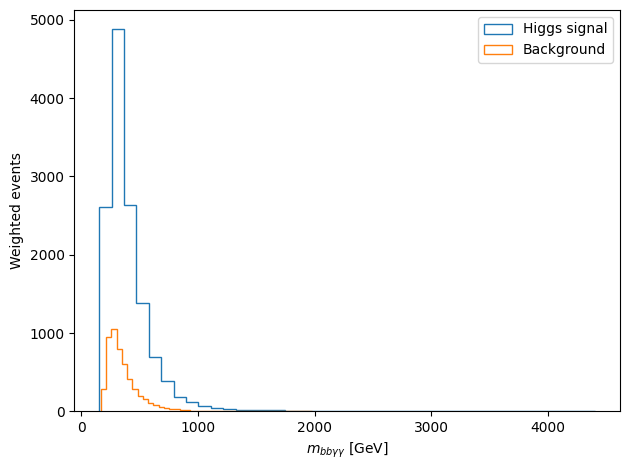

In [11]:
plt.hist(
    cbhim_1D_df.loc[label, 'm_bbyy'],
    bins=40,
    weights=weights[label],
    histtype='step',
    label='Higgs signal'
)

plt.hist(
    cbhim_1D_df.loc[~label, 'm_bbyy'],
    bins=40,
    weights=weights[~label],
    histtype='step',
    label='Background'
)

plt.xlabel(r'$m_{bb\gamma\gamma}$ [GeV]')
plt.ylabel('Weighted events')
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'cbgim_1D_df' is not defined

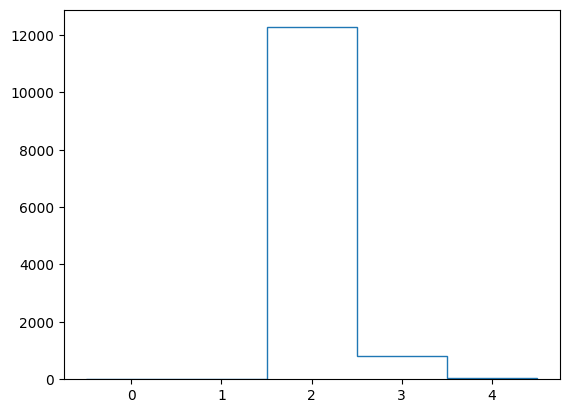

In [12]:
bins = [-0.5, 0.5, 1.5, 2.5, 3.5, 4.5]

plt.hist(
    cbhim_1D_df.loc[label, 'nBTaggedJets'],
    bins=bins,
    weights=weights[label],
    histtype='step',
    label='Signal'
)

plt.hist(
    cbgim_1D_df.loc[~label, 'nBTaggedJets'],
    bins=bins,
    weights=weights[~label],
    histtype='step',
    label='Background'
)

plt.xlabel('Number of b-tagged jets')
plt.ylabel('Weighted events')
plt.legend()
plt.tight_layout()
plt.show()


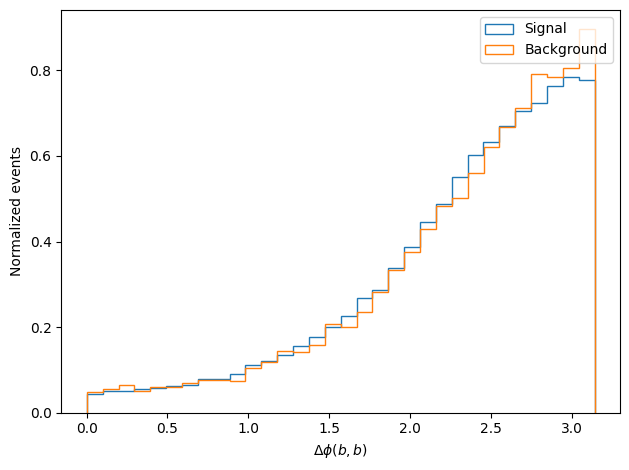

In [13]:
plt.hist(
    cbhim_1D_df.loc[label, 'DPhi_bb'],
    bins=32,
    weights=weights[label],
    histtype='step',
    density=True,
    label='Signal'
)

plt.hist(
    cbhim_1D_df.loc[~label, 'DPhi_bb'],
    bins=32,
    weights=weights[~label],
    histtype='step',
    density=True,
    label='Background'
)

plt.xlabel(r'$\Delta\phi(b,b)$')
plt.ylabel('Normalized events')
plt.legend()
plt.tight_layout()
plt.show()


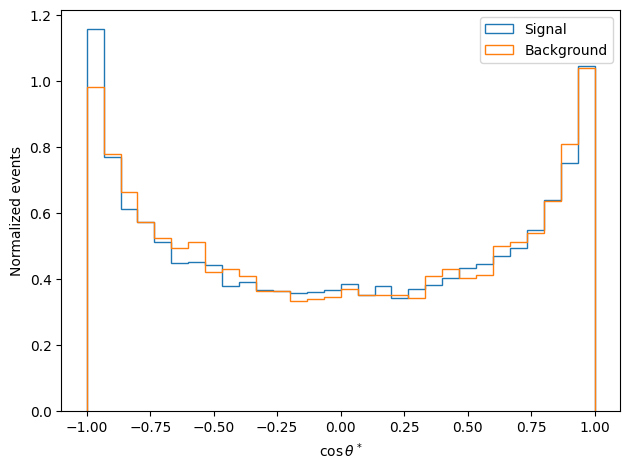

In [14]:
plt.hist(
    cbhim_1D_df.loc[label, 'cosThetaStar'],
    bins=30,
    weights=weights[label],
    histtype='step',
    density=True,
    label='Signal'
)

plt.hist(
    cbhim_1D_df.loc[~label, 'cosThetaStar'],
    bins=30,
    weights=weights[~label],
    histtype='step',
    density=True,
    label='Background'
)

plt.xlabel(r'$\cos\theta^*$')
plt.ylabel('Normalized events')
plt.legend()
plt.tight_layout()
plt.show()


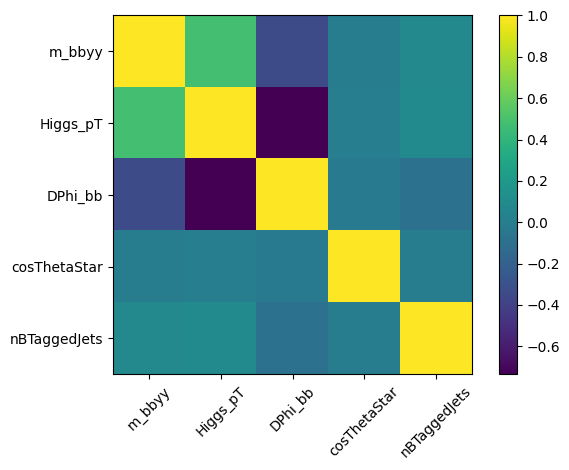

In [15]:
vars_to_check = [
    'm_bbyy',
    'Higgs_pT',
    'DPhi_bb',
    'cosThetaStar',
    'nBTaggedJets'
]

corr = cbhim_1D_df.loc[label, vars_to_check].corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(vars_to_check)), vars_to_check, rotation=45)
plt.yticks(range(len(vars_to_check)), vars_to_check)
plt.tight_layout()
plt.show()
